# Voxel-wise Permutation Testing demo

## Data simulation 

We simulate a null fMRI dataset with no true activation.  
For each subject ( i = 1, ... , n ), we generate a 2-D image Yi(x, y)  of size S*S (Currently S = 64) voxels.

### 1. Noise generation

Each voxel is drawn independently from a normal distribution:

$$
Y_i(x, y) \sim \mathrm{Normal}(0, 1).
$$


### 2. Smoothing

To introduce spatial correlation, each image is convolved with a 
Gaussian smoothing kernel.

### 3. Final dataset

The simulated null dataset is:

$$
\{\, Y_i^{\text{smooth}}(x,y) \;:\; i=1,\dots,n \,\}
$$

with no true activation anywhere in the image.

# Models Used:

# One sample model (no labels)

Each voxel has observations:

$$
y = (y_1, y_2, \ldots, y_n)^\top.
$$

The design matrix is

$$
X =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix}
\quad (n \times 1).
$$

The model is:

$$
y = X\beta + \varepsilon,
$$

where

- $\beta$ is the mean activation,  
- $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.


The null hypothesis is

$$
H_0: \beta(v) = 0,
$$

that is, the mean signal at voxel \(v\) is zero.


The alternative hypothesis is

$$
H_1: \beta(v) \neq 0.
$$



### Contrast

$$
L = [1].
$$

### t statistic

$$
t(v) = \frac{L^\top \hat{\beta}(v)}{\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

# Two sample model (with labels)

Let the subjects be in two equal groups.

The design matrix is

$$
X =
\begin{bmatrix}
1 & 0 \\
\vdots & \vdots \\
1 & 0 \\
0 & 1 \\
\vdots & \vdots \\
0 & 1
\end{bmatrix}
\quad (n \times 2).
$$

The model:

$$
y = X\beta + \varepsilon,
$$

with

$$
\beta =
\begin{bmatrix}
\mu_1 \\
\mu_2
\end{bmatrix},
\qquad
\varepsilon \sim \mathcal{N}(0, \sigma^2 I).
$$

### Contrast

$$
L = [\,1,\ -1\,].
$$

Tests:

$$
H_0:\ \mu_1 - \mu_2 = 0.
$$

### t statistic

$$
t(v) = 
\frac{L^\top \hat{\beta}(v)}
     {\sqrt{\hat{\sigma}^2(v)\, L^\top (X^\top X)^{-1} L}}.
$$


---

## Permutation Methods

### One sample (sign flipping)

Under the null:

$$
y_i^{new} = s_i\, y_i, \qquad s_i \in \{-1, +1\}.
$$

Each subject's sign is flipped independently with a 50:50 chance.


### Two sample (label shuffling)

Under the null, labels are exchangeable:

$$
X^{new} = \text{random permutation of rows of } X.
$$

This keeps the same number of subjects per group.


### Distribution of max T value

For each permutation

$$
m_p = \max_v \bigl|t_p(v)\bigr|.
$$


### Permutation threshold

$$
t_{\text{thr}} = \text{quantile}_{1-\alpha}(m_1,\dots,m_P).
$$


### Corrected significance map

$$
\text{sig}(v) = \mathbf{1}\{\,|t_{\text{real}}(v)| > t_{\text{thr}}\,\}.
$$

# FWER code demo

Import the helper function library

In [2]:
import helper_functions as hf
import plotters as pl
import importlib

from scipy.stats import norm, t, cauchy, poisson
from scipy.special import gamma
from scipy.ndimage import label as label_clusters
from scipy.stats import expon, probplot

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import numpy as np



Initialise the parameters

In [58]:
n_runs = 50		# Number of simulation runs for FWER estimation
n_subj = 20  			# Number of subjects in each group
img_side_length = 64    # Side length of the square brain image in voxels
smoothing_sigma = 1.5 	# Standard deviation for Gaussian smoothing
alpha = 0.05      		# Significance level for FWER
n_perm = 200		    # Number of permutations for permutation test
null_boundary = 1e-3   # Boundary value for null hypothesis in visualization

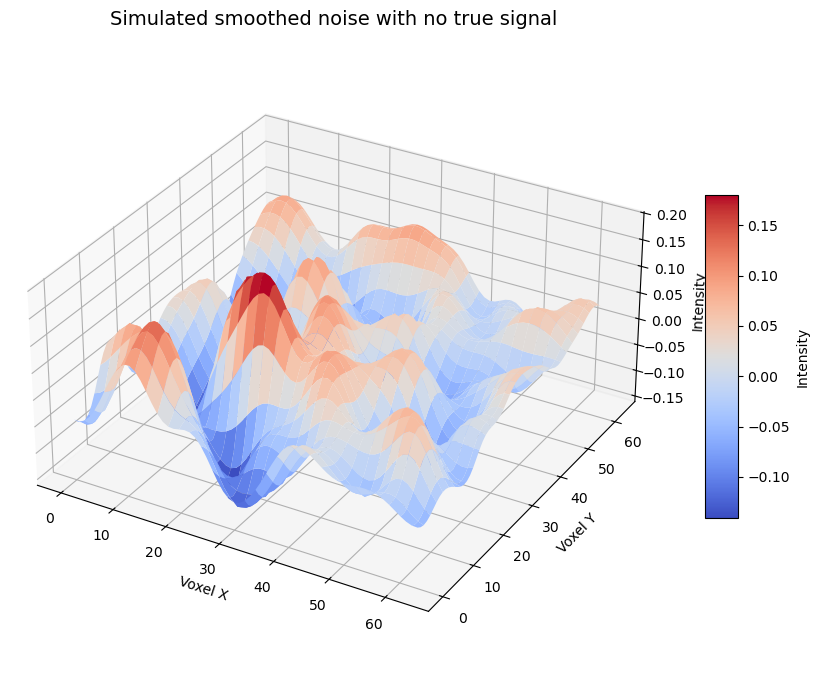

In [7]:
data = hf.simulate_null_data_2D(sigma = 3.7)
pl.plot_3d(data[0], title="Simulated smoothed noise with no true signal")

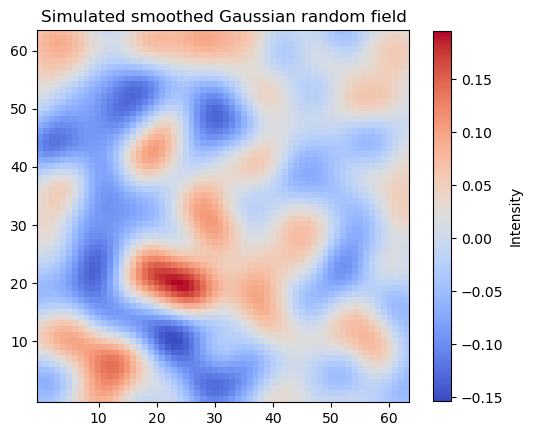

In [8]:
### Flatten Field
field = data[0]
nx, ny = field.shape

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    field, cmap='coolwarm', origin='lower', interpolation='none')

nx, ny = field.shape

tick_positions = list(range(10, nx, 10))
tick_labels    = list(range(10, nx, 10))

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.grid(color="lightgray", linewidth=0)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)

ax.set_title("Simulated smoothed Gaussian random field")
plt.colorbar(im, ax=ax, shrink=0.8, label="Intensity")
plt.show()

Gaussian Random field

We assume most of the maps generated are in gaussian shape, and we shall verify in that way before any simulation first

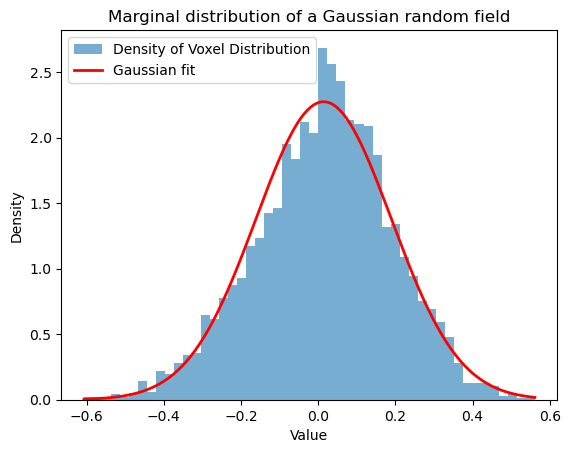

In [3]:
data = hf.simulate_null_data_2D(n_subj=20, img_side=64, sigma=1.5, method = "normal")
field = data[10]  # one realization

vals = field.ravel()


plt.hist(vals, bins=50, density=True, alpha=0.6, label="Density of Voxel Distribution")

# Overlay fitted Gaussian
mu, std = np.mean(vals), np.std(vals)
x = np.linspace(vals.min(), vals.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r', lw=2, label="Gaussian fit")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Marginal distribution of a Gaussian random field")
plt.legend()
plt.show()


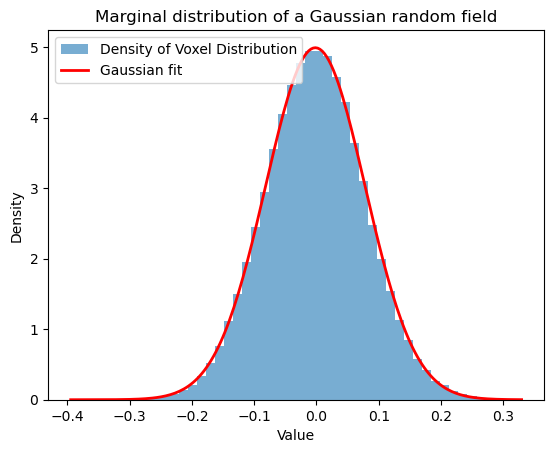

In [6]:
data = hf.simulate_null_data_3D(n_subj=20, img_side=64, sigma=1.5, method = "normal")
field = data[10]  # one realization

vals = field.ravel()


plt.hist(vals, bins=50, density=True, alpha=0.6, label="Density of Voxel Distribution")

# Overlay fitted Gaussian
mu, std = np.mean(vals), np.std(vals)
x = np.linspace(vals.min(), vals.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r', lw=2, label="Gaussian fit")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Marginal distribution of a Gaussian random field")
plt.legend()
plt.show()


Next, we would try to make different assumptions on random field and examine their potential result on simulation. 
We pick Truncated Cauchy and t-stat as an example and here are their visualisation of the results:

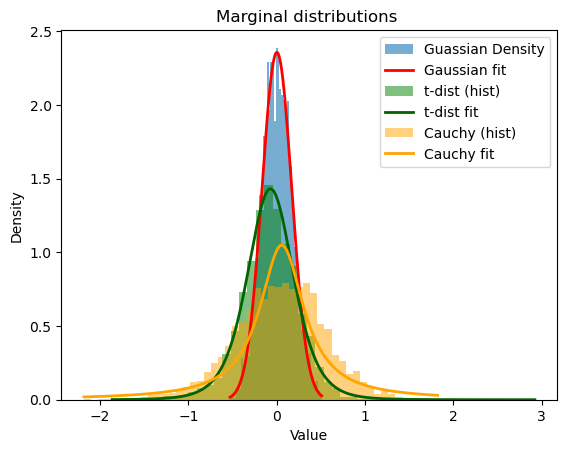

In [5]:
data_norm = hf.simulate_null_data_2D(n_subj=20, img_side=64, sigma=1.5, method = "normal")
field_norm = data_norm[10]  # one realization
vals_norm = field_norm.ravel()


plt.hist(vals_norm, bins=50, density=True, alpha=0.6, label="Guassian Density")

# Overlay fitted Gaussian
mu, std = np.mean(vals_norm), np.std(vals_norm)
x = np.linspace(vals_norm.min(), vals_norm.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r', lw=2, label="Gaussian fit")

#######
data_t = hf.simulate_null_data_2D(n_subj=20, img_side=64, sigma=1.5, method="t-dist")
field_t = data_t[10]
vals_t = field_t.ravel()

plt.hist(vals_t, bins=50, density=True, alpha=0.5,
         color="green", label="t-dist (hist)")

df_t, loc_t, scale_t = t.fit(vals_t)
x_t = np.linspace(vals_t.min(), vals_t.max(), 400)
plt.plot(x_t, t.pdf(x_t, df_t, loc_t, scale_t),
         color="darkgreen", lw=2, label="t-dist fit")

# ##########
data_cauchy = hf.simulate_null_data_2D(n_subj=20, img_side=64, sigma=1.5, method="cauchy")
field_cauchy = data_cauchy[10]
vals_cauchy = field_cauchy.ravel()

plt.hist(vals_cauchy, bins=50, density=True, alpha=0.5,
         color="orange", label="Cauchy (hist)")

loc_c, scale_c = cauchy.fit(vals_cauchy)
x_c = np.linspace(vals_cauchy.min(), vals_cauchy.max(), 400)
plt.plot(x_c, cauchy.pdf(x_c, loc_c, scale_c),
         color="orange", lw=2, label="Cauchy fit")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Marginal distributions ")
plt.legend()
plt.show()


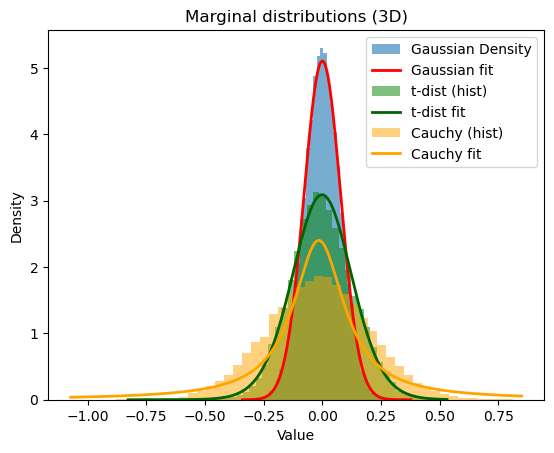

In [8]:
data_norm = hf.simulate_null_data_3D(n_subj=20, img_side=32, sigma=1.5, method="normal")
field_norm = data_norm[10]  # one realization (3D volume)
vals_norm = field_norm.ravel()

plt.hist(vals_norm, bins=50, density=True, alpha=0.6, label="Gaussian Density")

mu, std = np.mean(vals_norm), np.std(vals_norm)
x = np.linspace(vals_norm.min(), vals_norm.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), 'r', lw=2, label="Gaussian fit")

#######
data_t = hf.simulate_null_data_3D(n_subj=20, img_side=32, sigma=1.5, method="t-dist")
field_t = data_t[10]
vals_t = field_t.ravel()

plt.hist(vals_t, bins=50, density=True, alpha=0.5,
         color="green", label="t-dist (hist)")

df_t, loc_t, scale_t = t.fit(vals_t)
x_t = np.linspace(vals_t.min(), vals_t.max(), 400)
plt.plot(x_t, t.pdf(x_t, df_t, loc_t, scale_t),
         color="darkgreen", lw=2, label="t-dist fit")

# ##########
data_cauchy = hf.simulate_null_data_3D(n_subj=20, img_side=32, sigma=1.5, method="cauchy")
field_cauchy = data_cauchy[10]
vals_cauchy = field_cauchy.ravel()

plt.hist(vals_cauchy, bins=50, density=True, alpha=0.5,
         color="orange", label="Cauchy (hist)")

loc_c, scale_c = cauchy.fit(vals_cauchy)
x_c = np.linspace(vals_cauchy.min(), vals_cauchy.max(), 400)
plt.plot(x_c, cauchy.pdf(x_c, loc_c, scale_c),
         color="orange", lw=2, label="Cauchy fit")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Marginal distributions (3D)")
plt.legend()
plt.show()


Run the simulations and check the FWER error rate with no permutation correction applied

No labels (just 1 regressor in beta):

In [ ]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=False
)

print(fwer_false_pos_rate)

With A/B labels (2 regressors in beta):

In [ ]:
fwer_false_pos_rate = hf.estimate_fwer(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    alpha=alpha,
    labels=True
)

print(fwer_false_pos_rate)

In both cases, FWER is 1, which is very high, as expected.

## Clusterwise RFT Setup

In [ ]:
"""INPUT: tmap, sigma, threshold, fwer_alpha
├ W = sigma (or FWHM)
├ vol_size = tmap.size
├ D = tmap.ndim

├ exp_N = cal_exp_voxels_above_threshold(vol_size, threshold)
├ exp_m = compute_expected_clusters(vol_size, W, threshold, D)
├ beta = cal_beta_parameter(exp_m, exp_N, D)
├ k_c = compute_critical_cluster_size(exp_m, beta, D, fwer_alpha)
│
├ labeled, num_clusters = detect_clusters(tmap, threshold)
├ cluster_sizes = get_cluster_sizes(labeled)
│
└ FOR EACH cluster:
    ├ p_val = compute_cluster_p_value(size, exp_m, beta, D)
    └ IF p_val < fwer_alpha: mark as significant
    
"""

In [ ]:


# simulate_null_data(n_subj=20, img_side=64, sigma=1.5, snr=0, signal_radius=0)
def data_simulation_clusterwise_with_signal(n_subj=20, img_side=64, sigma=1.5, 
                                            snr=1.0, signal_radius=6, threshold=2.8, alpha=0.05):
    data = hf.simulate_null_data_2D(n_subj=n_subj, img_side=img_side, sigma=sigma, 
                                  snr=snr, signal_radius=signal_radius)
    X, L, df = hf.build_design_matrix(n_subj, labels=False)
    beta = hf.compute_beta_map(data, X)
    var = hf.compute_variance_map(data, X, beta)
    tmap = hf.compute_t_map(beta, X, L, var)
    
    sig_map, cluster_pvals, k_c, labeled, cluster_sizes = hf.rft_clusterwise_test(
        tmap=tmap, sigma=sigma, threshold=threshold, fwer_alpha=alpha)
    return sig_map, cluster_pvals, k_c, labeled, cluster_sizes

def estimate_fwer_rft_clusterwise(sig_map):
    return np.any(sig_map)

In [9]:
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng()
n_runs = 50		# Number of simulation runs for FWER estimation
n_subj = 20  			# Number of subjects in each group
img_side_length = 64    # Side length of the square brain image in voxels
smoothing_sigma = 3 	# Standard deviation for Gaussian smoothing
alpha = 0.05      		# Significance level for FWER
n_perm = 200		    # Number of permutations for permutation test
null_boundary = 1e-3   # Boundary value for null hypothesis in visualization
snr = 1

fwhm, tmap, res_map, df= hf.simulate_one_tmap(n_subj, img_side_length, smoothing_sigma, snr, signal_radius=6)


print("snr passed in:", snr)
print("sigma passed in:", smoothing_sigma)
d0 = rng.normal(size=(64,64))
d1 = gaussian_filter(d0, sigma=smoothing_sigma, mode="constant")
print(np.max(np.abs(d0-d1)))

print("Sigma", smoothing_sigma)
print("FWHM overall:", fwhm)


snr passed in: 1
sigma passed in: 3
3.8893593544089655
Sigma 3
FWHM overall: 7.162519186896765


## Verification of the Distribution

### 2D Simulation

In [26]:
importlib.reload(hf)
n_realizations = 1000
n_subj = 50
img_side_length = 128
smoothing_sigma = 3.0
u_list = [2.6, 2.8 ,3, 3.2, 3.6, 4.0, 4.2,4.4]

m_dict = {u: [] for u in u_list}
n_dict = {u: [] for u in u_list}

for _ in range(n_realizations):
    fwhm, tmap, res_map, df = hf.simulate_one_tmap(
        n_subj, img_side_length, smoothing_sigma,
        snr=0, signal_radius=0)

    zmap = hf.tmap_to_zmap(tmap, df)

    for u in u_list:
        detect_labeled, detect_num_clusters, cluster_sizes, sig_labeled, sig_num_clusters = \
            hf.detect_clusters(zmap, u, k_c=0)

        m_dict[u].append(detect_num_clusters)
        n_dict[u].extend(cluster_sizes.values())

vol_size = img_side_length ** 2
W = fwhm / np.sqrt(4 * np.log(2))

for u in u_list:
    # --- Cluster COUNT (m) → should be Poisson ---
    m_vals = np.array(m_dict[u])
    m_mean = m_vals.mean()
    m_var  = m_vals.var(ddof=1)
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=2)

    # --- Cluster SIZE (n) → should fit Exp Distribution ---
    n_vals = np.array(n_dict[u])
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, u)
    beta_theo = theo_Em / exp_N
    n_mean = n_vals.mean()
    n_var  = n_vals.var(ddof=1)
    theo_n_mean = 1 / beta_theo

    print(f"u={u}:")
    print(f"  m (count):  mean={m_mean:.2f}, var={m_var:.2f}, "
          f"E{{m}}={theo_Em:.2f}, mean/var={m_mean/m_var:.2f} (≈1 for Poisson)")
    print(f"  n (size):   mean={n_mean:.2f}, E{{n}}={theo_n_mean:.2f}, "
          f"var/mean²={n_var/n_mean**2:.2f} (≈1 for Exponential)")


u=2.6:
  m (count):  mean=5.42, var=5.17, E{m}=4.90, mean/var=1.05 (≈1 for Poisson)
  n (size):   mean=14.32, E{n}=15.60, var/mean²=0.97 (≈1 for Exponential)
u=2.8:
  m (count):  mean=3.39, var=3.18, E{m}=3.07, mean/var=1.06 (≈1 for Poisson)
  n (size):   mean=12.60, E{n}=13.62, var/mean²=0.95 (≈1 for Exponential)
u=3:
  m (count):  mean=2.08, var=2.08, E{m}=1.84, mean/var=1.00 (≈1 for Poisson)
  n (size):   mean=11.04, E{n}=12.00, var/mean²=0.92 (≈1 for Exponential)
u=3.2:
  m (count):  mean=1.19, var=1.22, E{m}=1.06, mean/var=0.98 (≈1 for Poisson)
  n (size):   mean=9.82, E{n}=10.64, var/mean²=0.90 (≈1 for Exponential)
u=3.6:
  m (count):  mean=0.36, var=0.35, E{m}=0.31, mean/var=1.01 (≈1 for Poisson)
  n (size):   mean=7.60, E{n}=8.53, var/mean²=0.84 (≈1 for Exponential)
u=4.0:
  m (count):  mean=0.09, var=0.09, E{m}=0.07, mean/var=1.00 (≈1 for Poisson)
  n (size):   mean=5.88, E{n}=6.99, var/mean²=0.84 (≈1 for Exponential)
u=4.2:
  m (count):  mean=0.04, var=0.04, E{m}=0.03, mean/v

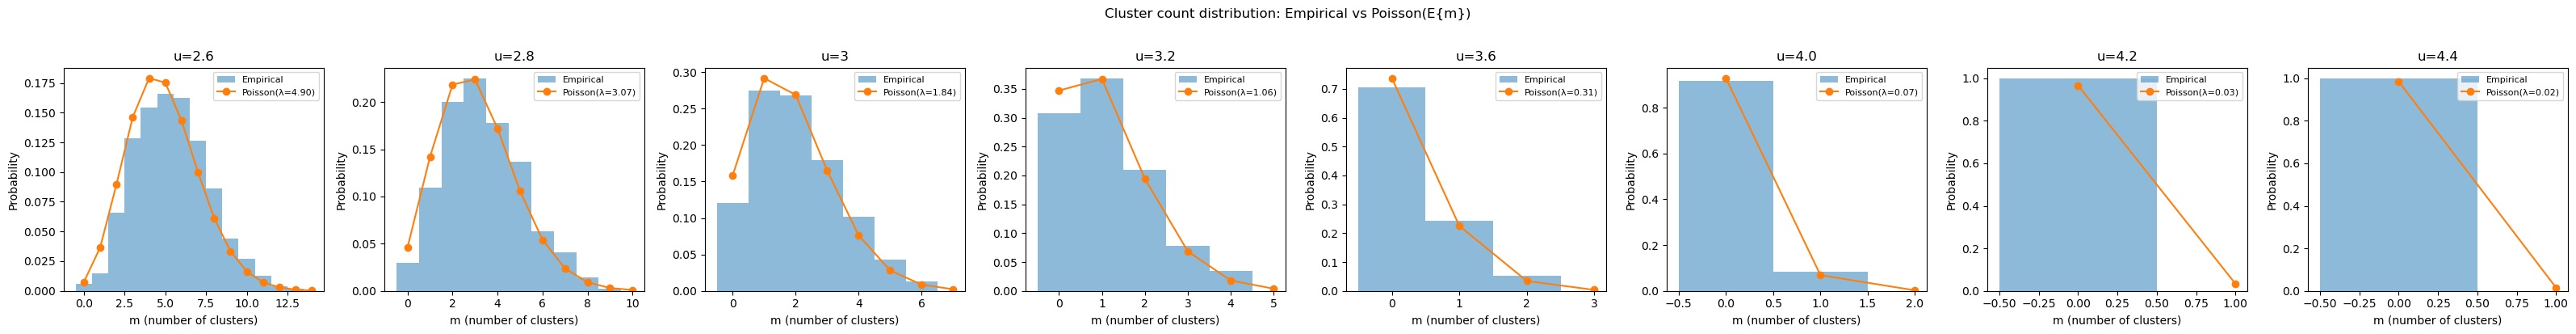

In [28]:
vol_size = img_side_length ** 2
W = fwhm / np.sqrt(4 * np.log(2))

fig, axes = plt.subplots(1, len(u_list), figsize=(4 * len(u_list), 4))

for i, u in enumerate(u_list):
    m_vals = np.array(m_dict[u])
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=2)

    xs = np.arange(0, m_vals.max() + 1)
    axes[i].hist(m_vals, bins=xs - 0.5, density=True, alpha=0.5, label="Empirical")
    axes[i].plot(xs, poisson.pmf(xs, theo_Em), "o-", label=f"Poisson(λ={theo_Em:.2f})")
    axes[i].set_xlabel("m (number of clusters)")
    axes[i].set_ylabel("Probability")
    axes[i].set_title(f"u={u}")
    axes[i].legend(fontsize=8)

plt.suptitle("Cluster count distribution: Empirical vs Poisson(E{m})", y=1.02)
plt.tight_layout()
plt.show()


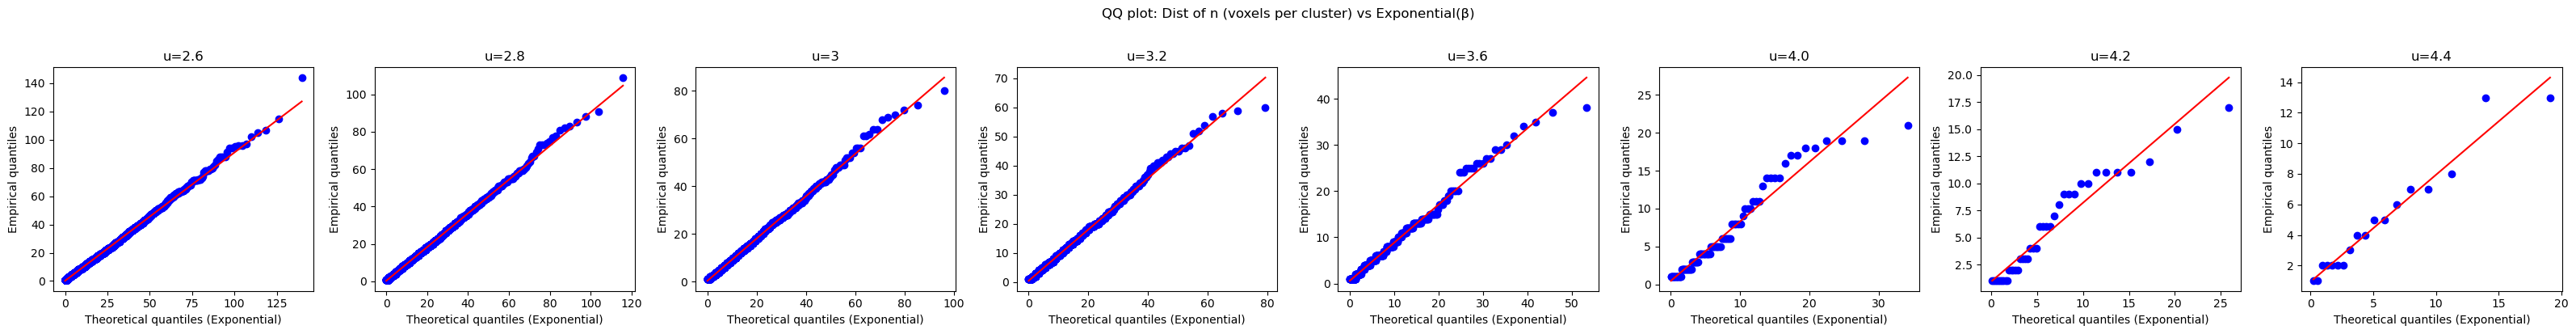

In [29]:
fig, axes = plt.subplots(1, len(u_list), figsize=(4 * len(u_list), 4))

for i, u in enumerate(u_list):
    n_vals = np.array(n_dict[u])
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=2)
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, u)
    beta_theo = theo_Em / exp_N

    # QQ plot against Exp(β) distribution
    # scipy's expon uses scale = 1/rate = 1/β
    probplot(n_vals, dist=expon, sparams=(0, 1 / beta_theo), plot=axes[i])
    axes[i].set_title(f"u={u}")
    axes[i].set_xlabel("Theoretical quantiles (Exponential)")
    axes[i].set_ylabel("Empirical quantiles")

plt.suptitle("QQ plot: Dist of n (voxels per cluster) vs Exponential(β)", y=1.02)
plt.tight_layout()
plt.show()


### 3D Simulation

In [3]:
importlib.reload(hf)
from tqdm.notebook import tqdm
hf.rng = np.random.default_rng(seed=2026)

n_realizations = 1000
n_subj = 50
smoothing_sigma = 3.0
img_side_length = 32
u_list = [2.6, 2.8, 3, 3.4,3.6, 3.8, 4, 4.2]

m_dict = {u: [] for u in u_list}
n_dict = {u: [] for u in u_list}

for _ in tqdm(range(n_realizations), desc="3D Realizations"):
    fwhm, tmap, res_map, df, true_mask = hf.simulate_one_tmap_test_3D(
        n_subj, img_side_length, smoothing_sigma,
        snr=0, signal_radius=0)

    zmap = hf.tmap_to_zmap(tmap, df)

    for u in u_list:
        detect_labeled, detect_num_clusters, cluster_sizes, sig_labeled, sig_num_clusters = \
            hf.detect_clusters_3D(zmap, u, k_c=0)

        m_dict[u].append(detect_num_clusters)
        n_dict[u].extend(cluster_sizes.values())

vol_size = img_side_length ** 3
W = fwhm / np.sqrt(4 * np.log(2))

for u in u_list:
    # --- Cluster COUNT (m) → should be Poisson ---
    m_vals = np.array(m_dict[u])
    m_mean = m_vals.mean()
    m_var  = m_vals.var(ddof=1)
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=3)

    # --- Cluster SIZE (n) → should fit Exp Distribution ---
    n_vals = np.array(n_dict[u])
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, u)
    beta_theo = theo_Em / exp_N
    n_mean = n_vals.mean()
    n_var  = n_vals.var(ddof=1)
    theo_n_mean = 1 / beta_theo

    print(f"u={u}:")
    print(f"  m (count):  mean={m_mean:.2f}, var={m_var:.2f}, "
          f"E{{m}}={theo_Em:.2f}, mean/var={m_mean/m_var:.2f} (≈1 for Poisson)")
    print(f"  n (size):   mean={n_mean:.2f}, E{{n}}={theo_n_mean:.2f}, "
          f"var/mean²={n_var/n_mean**2:.2f} (≈1 for Exponential)")


3D Realizations:   0%|          | 0/1000 [00:00<?, ?it/s]

u=2.6:
  m (count):  mean=2.68, var=2.37, E{m}=2.46, mean/var=1.13 (≈1 for Poisson)
  n (size):   mean=56.46, E{n}=62.05, var/mean²=2.28 (≈1 for Exponential)
u=2.8:
  m (count):  mean=1.80, var=1.61, E{m}=1.66, mean/var=1.12 (≈1 for Poisson)
  n (size):   mean=46.80, E{n}=50.33, var/mean²=2.26 (≈1 for Exponential)
u=3:
  m (count):  mean=1.17, var=1.16, E{m}=1.07, mean/var=1.01 (≈1 for Poisson)
  n (size):   mean=38.36, E{n}=41.37, var/mean²=2.38 (≈1 for Exponential)
u=3.4:
  m (count):  mean=0.42, var=0.42, E{m}=0.38, mean/var=1.00 (≈1 for Poisson)
  n (size):   mean=26.66, E{n}=28.91, var/mean²=2.24 (≈1 for Exponential)
u=3.6:
  m (count):  mean=0.22, var=0.23, E{m}=0.21, mean/var=0.97 (≈1 for Poisson)
  n (size):   mean=24.91, E{n}=24.53, var/mean²=1.84 (≈1 for Exponential)
u=3.8:
  m (count):  mean=0.13, var=0.13, E{m}=0.11, mean/var=0.95 (≈1 for Poisson)
  n (size):   mean=19.60, E{n}=20.98, var/mean²=1.79 (≈1 for Exponential)
u=4:
  m (count):  mean=0.06, var=0.07, E{m}=0.06, mea

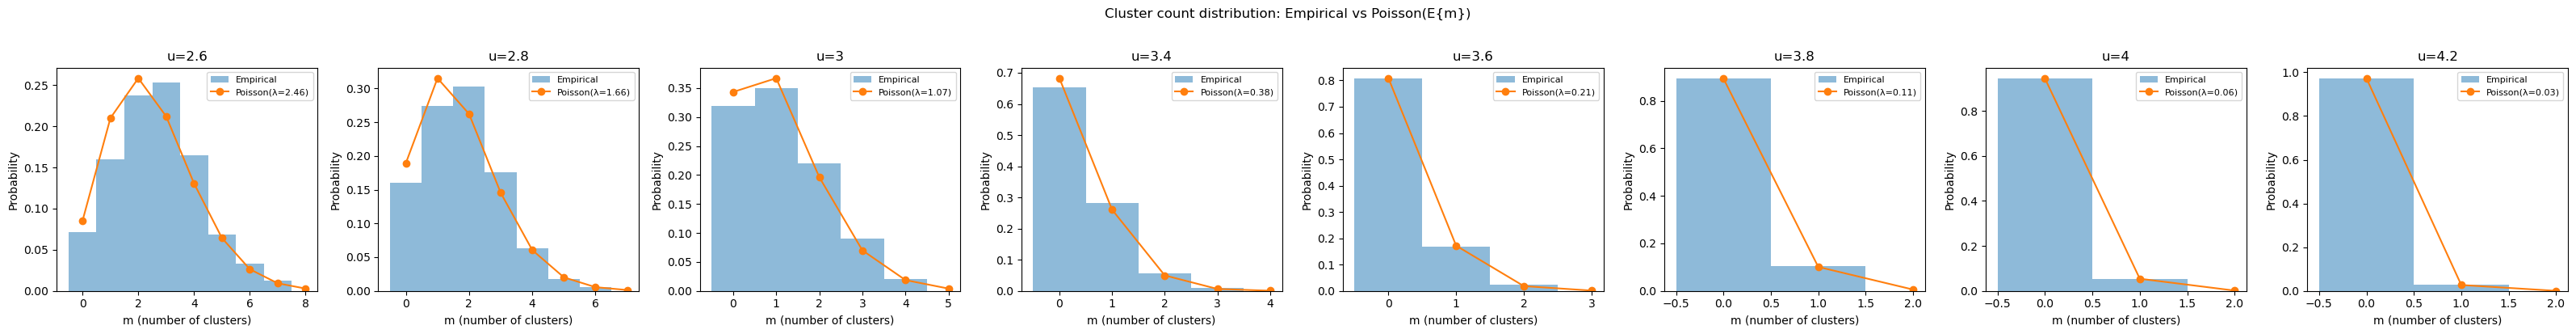

In [34]:
vol_size = img_side_length ** 3
W = fwhm / np.sqrt(4 * np.log(2))

fig, axes = plt.subplots(1, len(u_list), figsize=(4 * len(u_list), 4))

for i, u in enumerate(u_list):
    m_vals = np.array(m_dict[u])
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=3)

    xs = np.arange(0, m_vals.max() + 1)
    axes[i].hist(m_vals, bins=xs - 0.5, density=True, alpha=0.5, label="Empirical")
    axes[i].plot(xs, poisson.pmf(xs, theo_Em), "o-", label=f"Poisson(λ={theo_Em:.2f})")
    axes[i].set_xlabel("m (number of clusters)")
    axes[i].set_ylabel("Probability")
    axes[i].set_title(f"u={u}")
    axes[i].legend(fontsize=8)

plt.suptitle("Cluster count distribution: Empirical vs Poisson(E{m})", y=1.02)
plt.tight_layout()
plt.show()


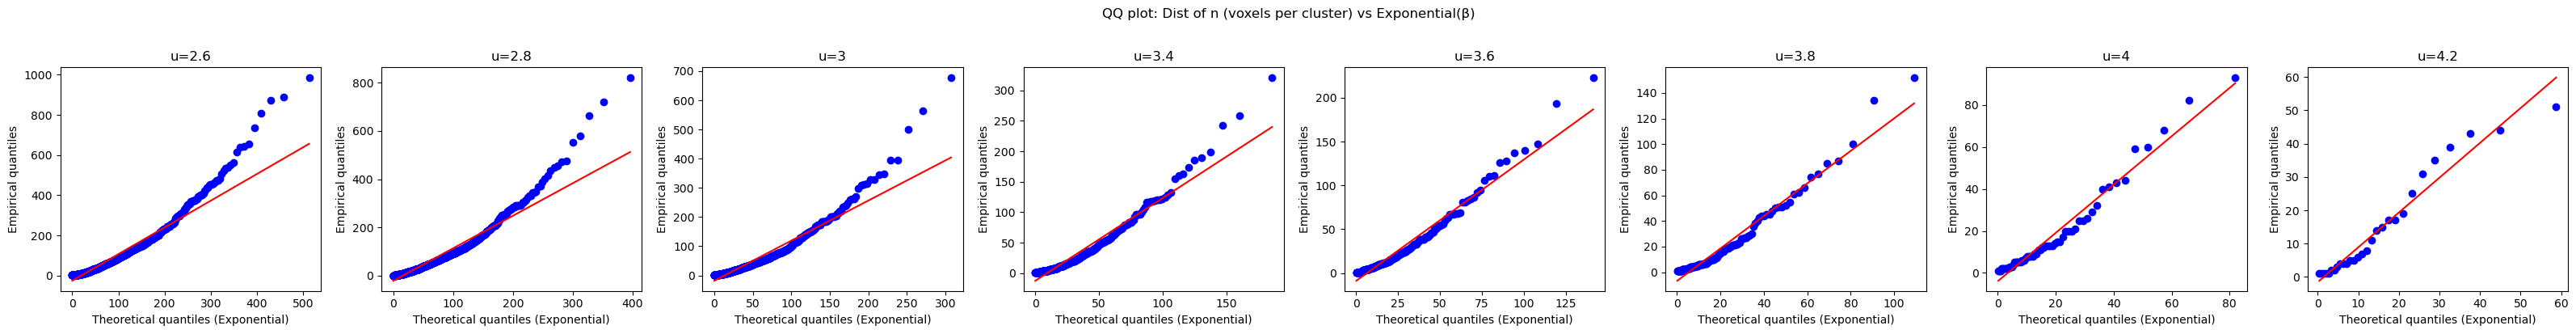

In [35]:
fig, axes = plt.subplots(1, len(u_list), figsize=(4 * len(u_list), 4))

for i, u in enumerate(u_list):
    n_vals = np.array(n_dict[u])
    theo_Em = hf.compute_expected_clusters(vol_size, W, u, D=3)
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, u)
    beta_theo = theo_Em / exp_N

    # QQ plot against Exp(β) distribution
    # scipy's expon uses scale = 1/rate = 1/β
    probplot(n_vals, dist=expon, sparams=(0, 1 / beta_theo), plot=axes[i])
    axes[i].set_title(f"u={u}")
    axes[i].set_xlabel("Theoretical quantiles (Exponential)")
    axes[i].set_ylabel("Empirical quantiles")

plt.suptitle("QQ plot: Dist of n (voxels per cluster) vs Exponential(β)", y=1.02)
plt.tight_layout()
plt.show()


## Validation on Critical sizes of k_c on Friston(1994) paper

In [47]:
# Table 1 reference values (FWHM=9.2, S=16384, D=2, α=0.05)
table1_kc = {2.4: 131, 2.6: 103, 2.8: 80, 3.0: 60, 3.2: 44,
             3.4: 30, 3.6: 18, 3.8: 8, 4.0: 4, 4.2: 3}

S = 16384       # 128 x 128
D = 2
FWHM = 9.2
W = FWHM / np.sqrt(4 * np.log(2))

thresholds = [2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2]
alphas = [0.10, 0.05, 0.01]

print(f"FWHM = {FWHM}, S = {S}, D = {D}, W = {W:.3f}")
print(f"{'u':<6}" + "".join(f"{a:<8}" for a in alphas))
print("-" * 30)

for u in thresholds:
    exp_m = hf.compute_expected_clusters(S, W, u, D)
    exp_N = hf.cal_exp_voxels_above_threshold(S, u)
    beta = hf.cal_beta_parameter(exp_m, exp_N, D)

    row = f"{u:<6.1f}"
    for a in alphas:
        k_c = hf.compute_critical_cluster_size(exp_m, beta, D, a)
        row += f"{k_c:<8.0f}"
    print(row)
print("-" * 30)

print(f"FWHM = {FWHM:.2f}, W = {W:.2f}, S = {128}, D = {D}")
print(f"{'u':<6}{'E{m}':<10}{'E{N}':<10}{'beta':<10}{'k_c':<10}{'Table1':<10}")
print("-" * 56)

for threshold in thresholds:
    fwhm, tmap, res_map, df = hf.simulate_one_tmap(n_subj=50, img_side_length=128, smoothing_sigma=3.85, snr=1, signal_radius=6)
    zmap = hf.tmap_to_zmap(tmap, df)

    vol_size = zmap.size
    D = zmap.ndim
    W = fwhm / np.sqrt(4 * np.log(2))
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, threshold)
    exp_m = hf.compute_expected_clusters(vol_size, W, threshold, D)
    beta = hf.cal_beta_parameter(exp_m, exp_N, D)
    k_c = np.ceil(hf.compute_critical_cluster_size(exp_m, beta, D))

    ref = table1_kc.get(round(threshold, 1), "-")
    print(f"{threshold:<6.1f}{exp_m:<10.2f}{exp_N:<10.2f}{beta:<10.4f}{k_c:<10.0f}{ref}")



FWHM = 9.2, S = 16384, D = 2, W = 5.525
u     0.1     0.05    0.01    
------------------------------
2.4   110     131     179     
2.6   85      103     144     
2.8   64      80      116     
3.0   46      60      92      
3.2   31      44      72      
3.4   19      30      55      
3.6   8       18      41      
3.8   1       8       28      
4.0   1       1       17      
4.2   1       1       8       
------------------------------
FWHM = 9.20, W = 5.53, S = 128, D = 2
u     E{m}      E{N}      beta      k_c       Table1    
--------------------------------------------------------
2.4   4.55      134.31    0.0339    133       131
2.6   3.00      76.37     0.0393    104       103
2.8   1.93      41.86     0.0462    79        80
3.0   1.13      22.12     0.0511    61        60
3.2   0.66      11.26     0.0585    44        44
3.4   0.36      5.52      0.0647    30        30
3.6   0.19      2.61      0.0722    19        18
3.8   0.09      1.19      0.0786    8         8
4.0   0.05  

In [ ]:
table1_kc_d3 = {2.4: 476, 2.6: 344, 2.8: 247, 3.0: 174, 3.2: 120,
             3.4: 79, 3.6: 49, 3.8: 27, 4.0: 12, 4.2: 3}

S = 40*40*40
D = 3
FWHM = 6.2
W = FWHM / np.sqrt(4 * np.log(2))
print(f"FWHM = {FWHM}, S = {S}, D = {D}, W = {W:.3f}")
print(f"{'u':<6}" + "".join(f"{a:<8}" for a in alphas))
print("-" * 30)

for u in thresholds:
    exp_m = hf.compute_expected_clusters(S, W, u, D)
    exp_N = hf.cal_exp_voxels_above_threshold(S, u)
    beta = hf.cal_beta_parameter(exp_m, exp_N, D)

    row = f"{u:<6.1f}"
    for a in alphas:
        k_c = hf.compute_critical_cluster_size(exp_m, beta, D, a)
        row += f"{k_c:<8.0f}"
    print(row)



for threshold in thresholds:
    fwhm, tmap, res_map, df, _ = hf.simulate_one_tmap_test_3D(
    n_subj=50, img_side_length=40, smoothing_sigma=2.58, snr=0, signal_radius=0)
    zmap = hf.tmap_to_zmap(tmap, df)
    vol_size = zmap.size
    D = zmap.ndim
    W = fwhm / np.sqrt(4 * np.log(2))
print(f"FWHM = {fwhm:.2f}, W = {W:.2f}, S = {S}, D = {D}")
print(f"{'u':<6}{'E{m}':<10}{'E{N}':<10}{'beta':<10}{'k_c':<10}{'Table1':<10}")
print("-" * 56)

for threshold in thresholds:
    exp_N = hf.cal_exp_voxels_above_threshold(vol_size, threshold)
    exp_m = hf.compute_expected_clusters(vol_size, W, threshold, D)
    beta = hf.cal_beta_parameter(exp_m, exp_N, D)
    k_c = np.ceil(hf.compute_critical_cluster_size(exp_m, beta, D))

    ref = table1_kc_d3.get(round(threshold, 1), "-")
    print(f"{threshold:<6.1f}{exp_m:<10.2f}{exp_N:<10.2f}{beta:<10.4f}{k_c:<10.0f}{ref}")


FWHM = 6.2, S = 64000, D = 3, W = 3.723
u     0.1     0.05    0.01    
------------------------------
2.4   380     473     707     
2.6   270     342     524     
2.8   189     245     387     
3.0   129     173     285     
3.2   85      119     207     
3.4   53      78      148     
3.6   29      48      103     
3.8   13      27      69      
4.0   3       12      43      
4.2   1       3       24      
FWHM = 6.23, W = 3.74, S = 64000, D = 3
u     E{m}      E{N}      beta      k_c       Table1    
--------------------------------------------------------
6.226760905526888
2.4   10.02     524.64    0.0864    478       476
2.6   7.13      298.32    0.1004    345       344
2.8   4.82      163.53    0.1154    248       247
3.0   3.10      86.39     0.1315    175       174
3.2   1.90      43.98     0.1487    120       120
3.4   1.11      21.56     0.1670    79        79
3.6   0.62      10.18     0.1864    49        49
3.8   0.33      4.63      0.2068    27        27
4.0   0.17      2.0

## Actual Test

### FWER Simulation

In [52]:
importlib.reload(hf)
hf.rng = np.random.default_rng(seed=2026)
## simple simulation
detect_counts = []
sig_counts = []

threshold = 3
no_simulation = 500
n_subj_list          = [2,5,7,10,15,20,30,45,60]
for n_subj in n_subj_list:
    decisions = []
    for i in range(no_simulation):
        FWHM, tmap, res_map, df, true_mask = hf.simulate_one_tmap_test(
            n_subj, img_side_length=64, smoothing_sigma=1, snr=1, signal_radius=6)
        zmap = hf.tmap_to_zmap(tmap, df)
        detect_labeled, detect_num_clusters, cluster_sizes, sig_labeled, sig_num_clusters = \
            hf.Rft_clusterwise_indentification(zmap, res_map, threshold, fwer_alpha=0.05)
        
        #detect_counts.append(detect_num_clusters)
        #sig_counts.append(sig_num_clusters)

        decision = hf.RFT_cluster_verification(sig_labeled, true_mask, overlap_threshold=0)
        decisions.append(decision)

    detect_counts = np.array(detect_counts)
    sig_counts = np.array(sig_counts)
    decisions
    # print(f"Among {no_simulation} simulations:")
    # print(f"Detected clusters: min={detect_counts.min()}, max={detect_counts.max()}, mean={detect_counts.mean():.2f}")

    # print(f"Significant clusters:  min={sig_counts.min()}, max={sig_counts.max()}, mean={sig_counts.mean():.2f}")
    print(f"FWHM {FWHM}, sm_sigma {smoothing_sigma}")
    print(f"Correct decisions: {np.mean(decisions) * 100:.2f}%, FWER Rate: {(1-np.mean(decisions)) * 100:.2f}%")


FWHM 2.8910363857591768, sm_sigma 3.0
Correct decisions: 100.00%, FWER Rate: 0.00%
FWHM 2.95921297442056, sm_sigma 3.0
Correct decisions: 100.00%, FWER Rate: 0.00%
FWHM 2.9574235186652227, sm_sigma 3.0
Correct decisions: 100.00%, FWER Rate: 0.00%
FWHM 2.944294396819726, sm_sigma 3.0
Correct decisions: 100.00%, FWER Rate: 0.00%
FWHM 2.9297791707598977, sm_sigma 3.0
Correct decisions: 99.00%, FWER Rate: 1.00%
FWHM 2.9587870098020606, sm_sigma 3.0
Correct decisions: 98.60%, FWER Rate: 1.40%
FWHM 2.948384352133727, sm_sigma 3.0
Correct decisions: 99.00%, FWER Rate: 1.00%
FWHM 2.9657660513803292, sm_sigma 3.0
Correct decisions: 98.80%, FWER Rate: 1.20%
FWHM 2.9538244726084644, sm_sigma 3.0
Correct decisions: 98.20%, FWER Rate: 1.80%


In [55]:
importlib.reload(hf)
hf.rng = np.random.default_rng(seed=2026)

def clusterwise_RFT_Full_Test(sm_sigma_list, snr_list, n_subj_list, threshold_u_list, overlap_threshold,
                               img_side_length=64, signal_radius=6,
                               no_simulation=1000, fwer_alpha=0.05,method="normal"):
    print(f"{method}")
    results_df = pd.DataFrame(columns=["FWER", "sensitivity", "sm_sigma", "snr", "n_subj", "method", "threshold_u", "FWHM"])

    combos = [(s, snr, n, u)
              for s in sm_sigma_list
              for snr in snr_list
              for n in n_subj_list
              for u in threshold_u_list]

    for sm_sigma, snr, n_sub, u in tqdm(combos, desc="RFT Sweep"):  
        decisions = []
        sensitivities = []
        last_fwhm = 0

        for i in range(no_simulation):
            FWHM, tmap, res_map, df, true_mask = hf.simulate_one_tmap_test(
                n_subj=n_sub, img_side_length=img_side_length,
                smoothing_sigma=sm_sigma, snr=snr, signal_radius=signal_radius,method=method)
            zmap = hf.tmap_to_zmap(tmap, df)
            detect_labeled, detect_num_clusters, cluster_sizes, sig_labeled, sig_num_clusters = \
                hf.Rft_clusterwise_indentification(zmap, res_map, u, fwer_alpha)

            decision = hf.RFT_cluster_verification(sig_labeled, true_mask, overlap_threshold)
            decisions.append(decision)
            last_fwhm = FWHM

            # Sensitivity: proportion of true signal voxels detected
            sig_map = sig_labeled > 0
            true_positives = np.sum(sig_map & true_mask)
            total_signal = np.sum(true_mask)
            sens = true_positives / total_signal if total_signal > 0 else 0.0
            sensitivities.append(sens)

        FWER = 1 - np.mean(decisions)
        sensitivity = np.mean(sensitivities)

        results_df.loc[len(results_df)] = {
            "FWER": FWER,
            "sensitivity": sensitivity,
            "sm_sigma": sm_sigma,
            "snr": snr,
            "n_subj": n_sub,
            "method": "Clusterwise RFT",
            "threshold_u": u,
            "FWHM": last_fwhm
        }

    return results_df

In [ ]:
importlib.reload(hf)
from tqdm import tqdm
hf.rng = np.random.default_rng(seed=2026)

img_side_length = 64
signal_radius   = 6

sm_sigma_list    = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
snr_list         = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
# n_subj_list      = [2, 5, 7, 10, 15, 20, 30, 45, 60]
threshold_u_list = 3.8
no_simulation    = 1000
sm_sigma_list    = [1.5]
snr_list         = [1.75]
n_subj_list      = [40]


results_overlap0_df = hf.clusterwise_RFT_Full_Test(
    sm_sigma_list,
    snr_list,
    n_subj_list,
    threshold_u_list,
    overlap_threshold = 0,
    no_simulation=100,
    method ="normal"
)

#results_overlap0_df.to_csv("results_overlap_0_250sim_df.csv")

RFT 2D Sweep: 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]


In [70]:
results_overlap0_df

,FWER,sensitivity,sm_sigma,snr,n_subj,method,threshold_u,FWHM
0,0.047,0.625604,1.5,1.75,40,Clusterwise RFT,3.2,3.912021


In [ ]:
# t-dist 0.027	0.562018	1.5	1.75	40	Clusterwise RFT	3.2	3.916914 15.8s
# cauchy 0.021	0.48949	    1.5	1.75	40	Clusterwise RFT	3.2	3.905107 18.5s
# normal 0.047	0.625604	1.5	1.75	40	Clusterwise RFT	3.2	3.912021 12.4s


,FWER,sensitivity,sm_sigma,snr,n_subj,method,threshold_u,FWHM
0,0.027,0.562018,1.5,1.75,40,Clusterwise RFT,3.2,3.916914


In [8]:
importlib.reload(hf)
from tqdm import tqdm
hf.rng = np.random.default_rng(seed=2026)

img_side_length = 32
signal_radius   = 6
threshold_u_list = 3.2
no_simulation    = 100
sm_sigma_list    = [1.5]
snr_list         = [1.75]
n_subj_list      = [40]


results_overlap0_df = hf.clusterwise_RFT_Full_Test_3D(
    sm_sigma_list,
    snr_list,
    n_subj_list,
    threshold_u_list,
    img_side_length = img_side_length,
    overlap_threshold = 0,
    no_simulation=100,
    method ="t-dist"
)

#results_overlap0_df.to_csv("results_overlap_0_250sim_df.csv")

RFT 3D Sweep: 100%|██████████| 1/1 [00:14<00:00, 14.68s/it]


In [ ]:
#FWER	sensitivity	sm_sigma	snr	n_subj	method	threshold_u	FWHM
#0.35	0.588746	1.5	1.75	40	Clusterwise RFT 3D	3.2	3.86694	746.034028	4.64	1.0
#

results_overlap0_df

,FWER,sensitivity,sm_sigma,snr,n_subj,method,threshold_u,FWHM,k_c,clusters_detected,true_clusters
0,0.35,0.588746,1.5,1.75,40,Clusterwise RFT 3D,3.2,3.86694,746.034028,4.64,1.0


In [92]:
results_overlap0_df

,FWER,sensitivity,sm_sigma,snr,n_subj,method,threshold_u,FWHM,k_c,clusters_detected,true_clusters
0,0.35,0.590455,1.5,1.75,40,Clusterwise RFT 3D,3.2,3.892044,85.06257,35.9,1.0


In [ ]:
results_overlap_0_5_df = clusterwise_RFT_Full_Test(
    sm_sigma_list,
    snr_list,
    n_subj_list,
    threshold_u_list,
    overlap_threshold = 0.5,
    no_simulation=1000
)
results_overlap_0_5_df.to_csv("results_overlap_0_5_df.csv")

In [ ]:
sigma = 0.01
threshold = 2.5
snr = 1.0
signal_radius = 12


# Get ground truth masks
true_mask = hf.get_smoothed_truth_mask(img_side_length, img_side_length, sigma, signal_radius, null_boundary)
noise_mask = ~true_mask

print(f"Ground truth signal: {np.sum(true_mask)} voxels | noise: {np.sum(noise_mask)} voxels")
print("="*60)

# Initialize counters
fp_count = 0
sensitivities = []

for r in range(n_runs):
    # Use the simulation function WITH signal
    sig_map, cluster_pvals, k_c, labeled, cluster_sizes = data_simulation_clusterwise_with_signal(
        n_subj=n_subj, img_side=img_side_length, sigma=sigma, 
        snr=snr, signal_radius=signal_radius,
        threshold=threshold, alpha=alpha
    )
    
    # FWER: Check false positives in noise region
    if np.any(sig_map & noise_mask):
        fp_count += 1
    
    # Sensitivity: True positives in signal region
    true_positives = np.sum(sig_map & true_mask)
    total_signal = np.sum(true_mask)
    sens = true_positives / total_signal if total_signal > 0 else 0.0
    sensitivities.append(sens)
    
    # First run details
    if r == 0:
        print("\n>>> Trial 1 <<<")
        print(f"sigma: {sigma}")
        print(f"Threshold: {threshold} | k_c: {k_c:.1f} voxels")
        print(f"snr: {snr}")
        print(f"Clusters detected: {len(cluster_pvals)}")
        
        sig_clusters = {cid: pval for cid, pval in cluster_pvals.items() if pval < alpha}
        print(f"Significant clusters: {len(sig_clusters)}")
        
        if cluster_pvals:
            print(f"\nCluster details:")
            for cid, pval in cluster_pvals.items():
                size = cluster_sizes[cid]
                sig_marker = "✓" if pval < alpha else "✗"
                print(f"  Cluster {cid}: {size:3d} voxels, p={pval:.4f} {sig_marker}")
        
        print(f"\nSignificant voxels: {np.sum(sig_map)} total")
        print(f"  TP (signal): {true_positives} | FP (noise): {np.sum(sig_map & noise_mask)}")
        print(f"  Sensitivity: {sens:.3f}")
    
# FINAL RESULTS
print("FINAL RESULTS")

fwer_estimate = fp_count / n_runs
mean_sens = np.mean(sensitivities)
std_sens = np.std(sensitivities)

print(f"\n[FWER] False Positive Rate in noise region:")
print(f"  Runs with FP: {fp_count}/{n_runs}")
print(f"  Estimated FWER: {fwer_estimate:.3f} (target: {alpha})")
# print(f"  Difference: {fwer_estimate - alpha:+.3f}")

print(f"\n[Sensitivity] True Positive Rate in signal region:")
print(f"  Mean: {mean_sens:.3f} ± {std_sens:.3f}")
# print(f"  Range: [{np.min(sensitivities):.3f}, {np.max(sensitivities):.3f}]")
print("=" * 60)


----- RFT Simulation Settings -----
Data dist type: normal
Length of sm_sigma_list : 1
Length of snr_list      : 1
Length of n_subj_list   : 2
Threshold_u value       : 3.2
total parameter         : 2
Overlap threshold       : 0
Number of simulations   : 1000
-----------------------------------


RFT Sweep:   0%|          | 0/2 [00:00<?, ?it/s]

RFT Sweep: 100%|██████████| 2/2 [00:07<00:00,  3.59s/it]



# Performance Analysis: SNR, Smoothing, and "Net Utility"

In this section we are moving beyond just checking if the method is "safe" (controlling false positives). Now we want to know if it's actually **useful**. Can it find a signal if there is one?

We are running a **2-Parameter Sweep** changing two things at once: **Signal-to-Noise Ratio (SNR)** and **Smoothing ($\sigma$)**.


Here is an example of a simulated data with fake signal inserted:

In [ ]:
pl.plot_3d(hf.simulate_null_data_2D(snr = 3, signal_radius=6, sigma = 1.5)[0], title="Simulated smoothed noise with constructed signal (SNR = 3)")

In [ ]:
importlib.reload(pl)
pl.generate_multi_snr_viz(snr_list=[0.5, 3.0], null_boundary=0.001)

In [ ]:
test_snrs =     [0, 0.1, 0.175, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.175, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0] # Low smooth -> High smooth

# 2. Run Sweep
# n_runs=20 and n_perm=50 is LOW quality but fast
# High quality: n_runs=50, n_perm=100
sens_mat, fwer_mat = hf.run_2d_sweep(
    n_runs=20,          
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=0.05,
    signal_radius=6,
    n_perm=50,   
	null_boundary = null_boundary       
)

In [ ]:
importlib.reload(pl)


pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)

In [ ]:
importlib.reload(pl)
pl.plot_sensitivity_analysis(test_snrs, test_sigmas, sens_mat)

In [ ]:

pl.plot_fwer_stability(test_snrs, test_sigmas, fwer_mat, np.array(test_sigmas), np.array(test_snrs))